# Cálculo de Airgap a partir de RAOs de 6 Graus de Liberdade

Tradução em Python dos scripts MATLAB da pasta `RAOs` (`AirgapRAO.m`, `RAOs.m`).

Os arquivos `.mat` fornecidos (`RAOsEvenKeel.mat`, `RAOsFOWTC.mat`, `RAOsHeelTrim.mat`)
contêm tabelas de amplitude (`raoampt`) e fase (`raophat`) das RAOs de surge, sway, heave,
roll, pitch e yaw, indexadas por período de onda (`vetor_Ti`) e ângulo de incidência
(`vetor_ai`).

Para um ponto fixo $P$ da estrutura (aqui, um ponto de referência no convés/torre, com
origem no centro da torre na linha d'água) e cada combinação (período, ângulo), o modelo:
1. Converte a amplitude/fase de cada um dos 6 GDL num deslocamento harmônico do ponto $P$
   (translações diretas para surge/sway/heave; rotações de corpo rígido em torno do centro
   de massa `CM` para roll/pitch/yaw);
2. Soma os deslocamentos dos 6 GDL (partes em fase e em quadratura separadas);
3. Calcula o módulo do deslocamento resultante e o subtrai de uma referência de folga
   nominal, obtendo o **airgap** (distância remanescente entre a estrutura e a superfície
   livre) para cada período e ângulo de onda.

O resultado é visualizado como uma superfície `Airgap(período, ângulo)`.

In [1]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (habilita projection='3d')

## Função de cálculo do airgap a partir das RAOs de 6 GDL

Reproduz fielmente o laço duplo (período × ângulo) dos scripts originais: para cada DOF de
translação (surge, sway, heave) o deslocamento é uma escala direta da amplitude da RAO; para
cada DOF de rotação (roll, pitch, yaw) aplica-se a matriz de rotação de corpo rígido
correspondente ao ponto $P$ em torno do centro de massa `CM`, e o deslocamento é a diferença
entre a posição rotacionada e a posição original de $P$. A parte "em fase"/"em quadratura"
de cada contribuição vem de $[\cos(\text{fase}), \sin(\text{fase})]$.

In [2]:
def compute_airgap(vetor_Ti, vetor_ai, raoampt, raophat, P, CM, A, referencia):
    """Reproduz o cálculo de airgap dos scripts RAOs.m / AirgapRAO.m.

    raoampt, raophat: arrays (nTi, nai, 6) com amplitude e fase das RAOs
        (ordem dos GDL: surge, sway, heave, roll, pitch, yaw).
    P: ponto de interesse (origem no centro da torre, na linha d'água).
    CM: posição vertical do centro de massa em relação à origem.
    A: amplitude de onda considerada.
    referencia: vetor de folga nominal ([0,0,A] ou P-[0,0,A], conforme o script).
    """
    P = np.asarray(P, dtype=float)
    referencia = np.asarray(referencia, dtype=float)
    off = np.array([0.0, 0.0, -CM])
    addback = np.array([0.0, 0.0, CM])

    nTi, nai = len(vetor_Ti), len(vetor_ai)
    Airgap = np.zeros((nTi, nai, 3))

    for i in range(nTi):
        for j in range(nai):
            R = np.zeros((2, 3, 6))

            # Surge
            fase = np.deg2rad(raophat[i, j, 0])
            R[:, :, 0] = A * np.outer([np.cos(fase), np.sin(fase)], P) * np.array([raoampt[i, j, 0], 0, 0])

            # Sway
            fase = np.deg2rad(raophat[i, j, 1])
            R[:, :, 1] = A * np.outer([np.cos(fase), np.sin(fase)], [0, raoampt[i, j, 1], 0])

            # Heave
            fase = np.deg2rad(raophat[i, j, 2])
            R[:, :, 2] = A * np.outer([np.cos(fase), np.sin(fase)], [0, 0, raoampt[i, j, 2]])

            # Roll
            amp = np.deg2rad(raoampt[i, j, 3])
            cr, sr = np.cos(amp), np.sin(amp)
            Rot = np.array([[1, 0, 0], [0, cr, -sr], [0, sr, cr]])
            vec = Rot @ (P + off) + addback - P
            fase = np.deg2rad(raophat[i, j, 3])
            R[:, :, 3] = A * np.outer([np.cos(fase), np.sin(fase)], vec)

            # Pitch
            amp = np.deg2rad(raoampt[i, j, 4])
            cp, sp = np.cos(amp), np.sin(amp)
            Rot = np.array([[cp, 0, sp], [0, 1, 0], [-sp, 0, cp]])
            vec = Rot @ (P + off) + addback - P
            fase = np.deg2rad(raophat[i, j, 4])
            R[:, :, 4] = A * np.outer([np.cos(fase), np.sin(fase)], vec)

            # Yaw
            amp = np.deg2rad(raoampt[i, j, 5])
            cy, sy = np.cos(amp), np.sin(amp)
            Rot = np.array([[cy, -sy, 0], [sy, cy, 0], [0, 0, 1]])
            vec = Rot @ (P + off) + addback - P
            fase = np.deg2rad(raophat[i, j, 5])
            R[:, :, 5] = A * np.outer([np.cos(fase), np.sin(fase)], vec)

            total = R.sum(axis=2)                       # soma das contribuições dos 6 GDL
            modulo = np.sqrt((total ** 2).sum(axis=0))   # módulo do deslocamento resultante
            Airgap[i, j, :] = referencia - modulo

    return Airgap

## Airgap — casco em quilha reta (`AirgapRAO.m`, dados `RAOsEvenKeel.mat`)

Referência de folga nominal $[0,0,A]$: o airgap é a folga inicial menos o módulo do
deslocamento vertical resultante do ponto $P$.

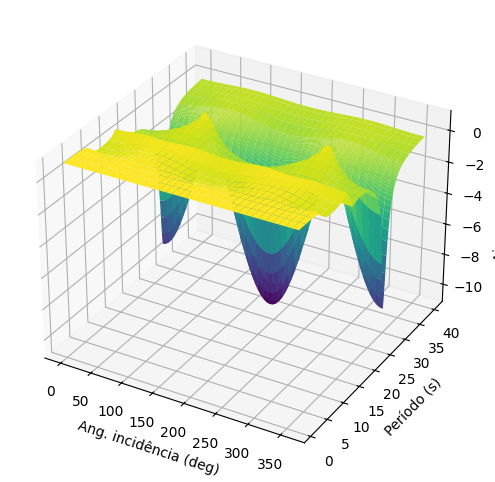

In [3]:
data = sio.loadmat('RAOsEvenKeel.mat')
vetor_Ti = data['vetor_Ti'].flatten()
vetor_ai = data['vetor_ai'].flatten()
raoampt = data['raoampt']
raophat = data['raophat']

P = np.array([70, 0, 15.5])   # origem no centro da torre e na linha d'água
CM = -11.72                   # posição do centro de massa em relação à origem
A = 1

referencia = np.array([0, 0, A])
Airgap_evenkeel = compute_airgap(vetor_Ti, vetor_ai, raoampt, raophat, P, CM, A, referencia)

AI, TI = np.meshgrid(vetor_ai, vetor_Ti)

fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(AI, TI, Airgap_evenkeel[:, :, 2], cmap='viridis')
ax.set_xlabel('Ang. incidência (deg)')
ax.set_ylabel('Período (s)')
ax.set_zlabel('Airgap - EvenKeel')
plt.show()

## Airgap — plataforma flutuante FOWT (`RAOs.m`, dados `RAOsFOWTC.mat`)

Mesmo cálculo, mas com referência de folga $P-[0,0,A]$ (folga medida a partir da posição
vertical do próprio ponto $P$, e não de uma folga nominal fixa).

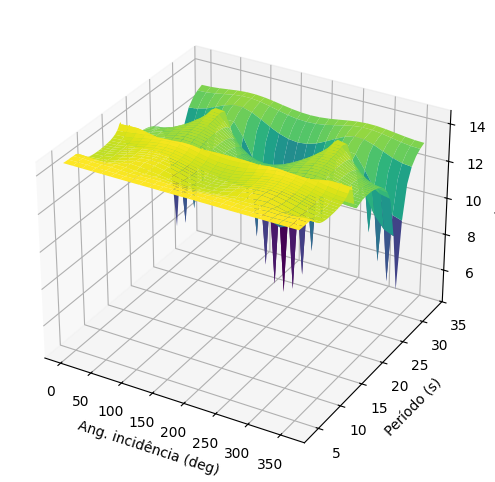

In [4]:
data = sio.loadmat('RAOsFOWTC.mat')
vetor_Ti = data['vetor_Ti'].flatten()
vetor_ai = data['vetor_ai'].flatten()
raoampt = data['raoampt']
raophat = data['raophat']

P = np.array([70, 0, 15.5])
CM = -11.72
A = 1

referencia = P - np.array([0, 0, A])
Airgap_fowtc = compute_airgap(vetor_Ti, vetor_ai, raoampt, raophat, P, CM, A, referencia)

AI, TI = np.meshgrid(vetor_ai, vetor_Ti)

fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(AI, TI, Airgap_fowtc[:, :, 2], cmap='viridis')
ax.set_xlabel('Ang. incidência (deg)')
ax.set_ylabel('Período (s)')
ax.set_zlabel('Airgap')
plt.show()